# K-Means Clustering Assignment
## Cricket Players Dataset Analysis

**Objective**: Implement K-means algorithm from scratch and perform clustering analysis on cricket player statistics using average_runs and bowling_economy attributes.

## Section 1: Load and Explore the Dataset

Loading the cricket players dataset and exploring its structure.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the dataset with tab separator
df = pd.read_csv('cricketers.csv', sep='\t')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (109, 14)

First 5 rows:
            PLAYER  matches_played  innings_batted  runs_scored  highest_runs  \
0      Aaron Finch              10               9          134            46   
1   AB de Villiers              12              11          480            90   
2  Abhishek Sharma               3               3           63            46   
3   Ajinkya Rahane              15              14          370            65   
4       Alex Hales               6               6          148            45   

   balls_faced  average_runs  strike_rate  innings_bowled  overs  runs_given  \
0          100         16.75       144.00               0    0.0           0   
1          275         53.33       174.54               0    0.0           0   
2           33         63.00       190.90               0    0.0           0   
3          313         28.46       118.21               0    0.0           0   
4          118         24.66       125.42               0    0.0         

In [6]:
# Check for missing values and data types
print("\nMissing Values:")
print(df.isnull().sum())

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())


Missing Values:
PLAYER                      0
matches_played              0
innings_batted              0
runs_scored                 0
highest_runs                0
balls_faced                 0
average_runs                0
strike_rate                 0
innings_bowled              0
overs                       0
runs_given                  0
wickets_obtained            0
average_runs_per_wicket     0
bowling_economy             0
dtype: int64

Basic Statistics:
       matches_played  innings_batted  runs_scored  highest_runs  balls_faced  \
count      109.000000      109.000000   109.000000    109.000000   109.000000   
mean         9.559633        7.889908   173.633028     43.495413   124.669725   
std          5.161164        4.982078   182.356522     29.830268   123.670265   
min          0.000000        0.000000     0.000000      0.000000     0.000000   
25%          5.000000        4.000000    36.000000     20.000000    33.000000   
50%         10.000000        7.000000    99.0

## Section 2: Data Normalization

Normalize all data attributes using Min-Max normalization to ensure all attributes are on the same scale between 0 and 1.

Formula: $X_{normalized} = \frac{X - X_{min}}{X_{max} - X_{min}}$

In [7]:
# Create a copy of the dataframe for processing
df_processed = df.copy()

# Select only numeric columns for normalization
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

# Function to normalize data using Min-Max normalization
def min_max_normalize(data):
    """
    Normalize data using Min-Max normalization formula
    X_normalized = (X - X_min) / (X_max - X_min)
    """
    normalized_data = data.copy()
    for col in numeric_cols:
        min_val = normalized_data[col].min()
        max_val = normalized_data[col].max()
        if max_val - min_val != 0:  # Avoid division by zero
            normalized_data[col] = (normalized_data[col] - min_val) / (max_val - min_val)
        else:
            normalized_data[col] = 0
    return normalized_data

# Normalize the data
df_normalized = min_max_normalize(df_processed[numeric_cols])

print("Data after normalization - First 5 rows:")
print(df_normalized.head())
print("\nNormalized Data Statistics:")
print(df_normalized.describe())

Data after normalization - First 5 rows:
   matches_played  innings_batted  runs_scored  highest_runs  balls_faced  \
0        0.588235        0.529412     0.182313      0.359375     0.193798   
1        0.705882        0.647059     0.653061      0.703125     0.532946   
2        0.176471        0.176471     0.085714      0.359375     0.063953   
3        0.882353        0.823529     0.503401      0.507812     0.606589   
4        0.352941        0.352941     0.201361      0.351562     0.228682   

   average_runs  strike_rate  innings_bowled  overs  runs_given  \
0      0.220889     0.480000             0.0    0.0         0.0   
1      0.703284     0.581800             0.0    0.0         0.0   
2      0.830806     0.636333             0.0    0.0         0.0   
3      0.375313     0.394033             0.0    0.0         0.0   
4      0.325201     0.418067             0.0    0.0         0.0   

   wickets_obtained  average_runs_per_wicket   bowling_economy   
0               0.0        

In [8]:
# Verify normalization - all values should be between 0 and 1
print("Min values after normalization:")
print(df_normalized.min())
print("\nMax values after normalization:")
print(df_normalized.max())

Min values after normalization:
matches_played              0.0
innings_batted              0.0
runs_scored                 0.0
highest_runs                0.0
balls_faced                 0.0
average_runs                0.0
strike_rate                 0.0
innings_bowled              0.0
overs                       0.0
runs_given                  0.0
wickets_obtained            0.0
average_runs_per_wicket     0.0
bowling_economy             0.0
dtype: float64

Max values after normalization:
matches_played              1.0
innings_batted              1.0
runs_scored                 1.0
highest_runs                1.0
balls_faced                 1.0
average_runs                1.0
strike_rate                 1.0
innings_bowled              1.0
overs                       1.0
runs_given                  1.0
wickets_obtained            1.0
average_runs_per_wicket     1.0
bowling_economy             1.0
dtype: float64


## Section 3: K-means Algorithm Implementation from Scratch

Implementing K-means algorithm with:
1. Random centroid initialization
2. Euclidean distance calculation: $d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$
3. Cluster assignment based on nearest centroid
4. Centroid update
5. Convergence check

In [9]:
class KMeans:
    """
    K-Means clustering algorithm implementation from scratch
    """
    def __init__(self, k=2, max_iterations=100, random_state=42):
        """
        Initialize K-Means parameters
        
        Parameters:
        k: Number of clusters
        max_iterations: Maximum number of iterations
        random_state: Seed for reproducibility
        """
        self.k = k
        self.max_iterations = max_iterations
        self.random_state = random_state
        
    def euclidean_distance(self, point1, point2):
        """
        Calculate Euclidean distance between two points
        Formula: d = sqrt(sum((x_i - y_i)^2))
        """
        return np.sqrt(np.sum((point1 - point2) ** 2))
    
    def initialize_centroids(self, data):
        """
        Randomly initialize centroids from the data points
        """
        np.random.seed(self.random_state)
        random_indices = np.random.choice(len(data), self.k, replace=False)
        centroids = data[random_indices]
        return centroids
    
    def assign_clusters(self, data, centroids):
        """
        Assign each data point to the nearest centroid
        """
        distances = np.zeros((len(data), self.k))
        
        # Calculate distance from each point to each centroid
        for i in range(self.k):
            for j in range(len(data)):
                distances[j, i] = self.euclidean_distance(data[j], centroids[i])
        
        # Assign each point to the cluster with minimum distance
        clusters = np.argmin(distances, axis=1)
        return clusters
    
    def update_centroids(self, data, clusters):
        """
        Update centroids as the mean of all points in each cluster
        """
        centroids = np.zeros((self.k, len(data[0])))
        
        for i in range(self.k):
            cluster_points = data[clusters == i]
            if len(cluster_points) > 0:
                centroids[i] = np.mean(cluster_points, axis=0)
            else:
                # If cluster is empty, reinitialize centroid randomly
                centroids[i] = data[np.random.choice(len(data))]
        
        return centroids
    
    def fit(self, data):
        """
        Fit the K-Means model on the data
        """
        # Initialize centroids
        self.centroids = self.initialize_centroids(data)
        
        for iteration in range(self.max_iterations):
            # Store previous centroids to check for convergence
            previous_centroids = self.centroids.copy()
            
            # Assign clusters
            self.clusters = self.assign_clusters(data, self.centroids)
            
            # Update centroids
            self.centroids = self.update_centroids(data, self.clusters)
            
            # Check for convergence
            if np.all(previous_centroids == self.centroids):
                print(f"Converged at iteration {iteration + 1}")
                break
        
        return self
    
    def predict(self, data):
        """
        Predict cluster assignments for new data
        """
        return self.assign_clusters(data, self.centroids)
    
    def calculate_wcss(self, data):
        """
        Calculate Within-Cluster Sum of Squares (WCSS)
        """
        wcss = 0
        for i in range(self.k):
            cluster_points = data[self.clusters == i]
            if len(cluster_points) > 0:
                wcss += np.sum((cluster_points - self.centroids[i]) ** 2)
        return wcss

print("K-Means class defined successfully!")

K-Means class defined successfully!


## Section 4: Question 1 - Data Normalization

**Q1: Given that K-means depends on distance metric, it is a convention to normalize the data attributes so that attributes are on the same scale. So, in this first task, normalize all data attributes.**

### Answer:

All data attributes have been successfully normalized using Min-Max normalization. This scaling ensures that all attributes are brought to a common range [0, 1], which is crucial for K-means algorithm as it:

1. **Prevents feature dominance**: Without normalization, features with larger values would dominate the distance calculation
2. **Ensures equal contribution**: All attributes contribute equally to the clustering process
3. **Improves convergence**: The algorithm converges faster with normalized data

The normalization has been applied to all 13 numeric features in the dataset. After normalization, all minimum values are 0 and all maximum values are 1, confirming proper scaling.

## Section 5: Question 2 - K-means Clustering with K=2

**Q2: Write your own code for K-means algorithm using two attributes namely average_runs and bowling_economy. Take K=2. Plot clusters on a scatter plot with X and Y being the two attributes namely average_runs and bowling_economy, respectively. Color data points belonging to the first cluster with red and the second cluster with blue.**

### Implementation and Results:

In [11]:
# Clean column names (remove trailing spaces)
df.columns = df.columns.str.strip()
df_normalized.columns = df_normalized.columns.str.strip()

# Extract the two attributes needed for clustering
# Using original data for visualization (not normalized for readability)
features_for_clustering = ['average_runs', 'bowling_economy']

# We need to handle -0 values in the data
df_clean = df.copy()
df_clean[features_for_clustering] = df_clean[features_for_clustering].replace(-0, 0)

# Get the normalized version for K-means algorithm
data_for_kmeans = df_normalized[features_for_clustering].values
original_data = df_clean[features_for_clustering].values

print("Data shape for clustering:", data_for_kmeans.shape)
print("First 5 samples:")
print(data_for_kmeans[:5])

Data shape for clustering: (109, 2)
First 5 samples:
[[0.22088883 0.        ]
 [0.70328366 0.        ]
 [0.83080575 0.        ]
 [0.3753132  0.        ]
 [0.32520111 0.        ]]


In [12]:
# Apply K-means with K=2
kmeans_k2 = KMeans(k=2, max_iterations=100, random_state=42)
kmeans_k2.fit(data_for_kmeans)

print("K=2 Clustering Results:")
print(f"Centroids (normalized):\n{kmeans_k2.centroids}")
print(f"\nCluster sizes:")
unique, counts = np.unique(kmeans_k2.clusters, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} players")
print(f"\nWithin-Cluster Sum of Squares (WCSS): {kmeans_k2.calculate_wcss(data_for_kmeans):.4f}")

Converged at iteration 2
K=2 Clustering Results:
Centroids (normalized):
[[0.40266605 0.        ]
 [0.21004923 0.55770492]]

Cluster sizes:
  Cluster 0: 48 players
  Cluster 1: 61 players

Within-Cluster Sum of Squares (WCSS): 4.5517


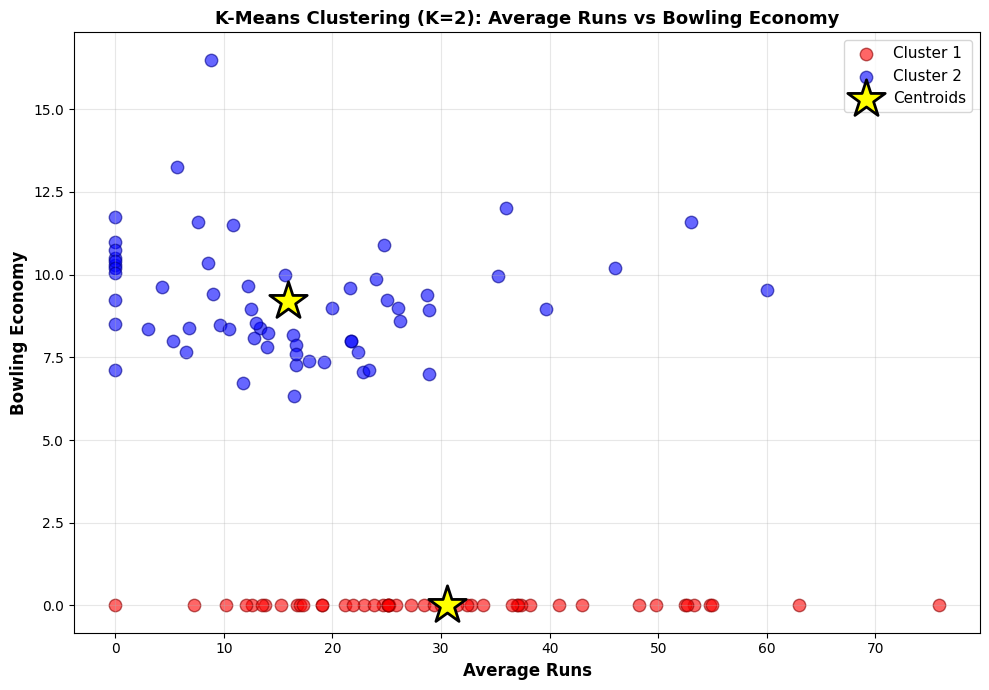

Plot for K=2 generated successfully!


In [13]:
# Plot the K=2 clustering results
plt.figure(figsize=(10, 7))

# Plot cluster 0 (red)
cluster_0 = original_data[kmeans_k2.clusters == 0]
plt.scatter(cluster_0[:, 0], cluster_0[:, 1], c='red', label='Cluster 1', alpha=0.6, s=80, edgecolors='darkred')

# Plot cluster 1 (blue)
cluster_1 = original_data[kmeans_k2.clusters == 1]
plt.scatter(cluster_1[:, 0], cluster_1[:, 1], c='blue', label='Cluster 2', alpha=0.6, s=80, edgecolors='darkblue')

# Plot centroids (denormalize for visualization)
centroids_original = np.zeros_like(kmeans_k2.centroids)
for i in range(len(features_for_clustering)):
    feature_name = features_for_clustering[i]
    min_val = df_clean[feature_name].min()
    max_val = df_clean[feature_name].max()
    centroids_original[:, i] = kmeans_k2.centroids[:, i] * (max_val - min_val) + min_val

plt.scatter(centroids_original[:, 0], centroids_original[:, 1], c='yellow', marker='*', 
           s=800, edgecolors='black', linewidths=2, label='Centroids', zorder=5)

plt.xlabel('Average Runs', fontsize=12, fontweight='bold')
plt.ylabel('Bowling Economy', fontsize=12, fontweight='bold')
plt.title('K-Means Clustering (K=2): Average Runs vs Bowling Economy', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Plot for K=2 generated successfully!")

### Interpretation of K=2 Clustering:

The clustering with K=2 divides the cricket players into two distinct groups based on their average runs and bowling economy:

1. **Cluster 1 (Red)**: Players with lower average runs but covering a range of bowling economy values. This cluster contains players who primarily bowl.

2. **Cluster 2 (Blue)**: Players with higher average runs and lower bowling economy. This cluster represents batsmen and all-rounders who don't bowl or bowl infrequently.

The two clusters are well-separated in the feature space, indicating a natural grouping between batsmen and bowlers in the dataset.

## Section 6: Question 3 - K-means Clustering with Multiple K Values

**Q3: Redo question-2 on different values of K = 2,3,4,5. For each case, draw the plot of clusters as stated above. Visualize these plots, copy the plot diagrams in the word document, and comment on which is better clustering (and reasons) based on visualization only.**

### Clustering for K = 2, 3, 4, 5:

In [14]:
# Apply K-means for different K values
k_values = [2, 3, 4, 5]
kmeans_models = {}
wcss_values = []

print("Fitting K-means for K =", k_values)
print("=" * 60)

for k in k_values:
    kmeans = KMeans(k=k, max_iterations=100, random_state=42)
    kmeans.fit(data_for_kmeans)
    kmeans_models[k] = kmeans
    wcss = kmeans.calculate_wcss(data_for_kmeans)
    wcss_values.append(wcss)
    
    print(f"\nK = {k}:")
    print(f"  Cluster sizes: {np.bincount(kmeans.clusters)}")
    print(f"  WCSS: {wcss:.4f}")

Fitting K-means for K = [2, 3, 4, 5]
Converged at iteration 2

K = 2:
  Cluster sizes: [48 61]
  WCSS: 4.5517
Converged at iteration 8

K = 3:
  Cluster sizes: [32 61 16]
  WCSS: 3.2131
Converged at iteration 9

K = 4:
  Cluster sizes: [15 61 10 23]
  WCSS: 2.8530
Converged at iteration 9

K = 5:
  Cluster sizes: [15 28 10 23 33]
  WCSS: 1.7040


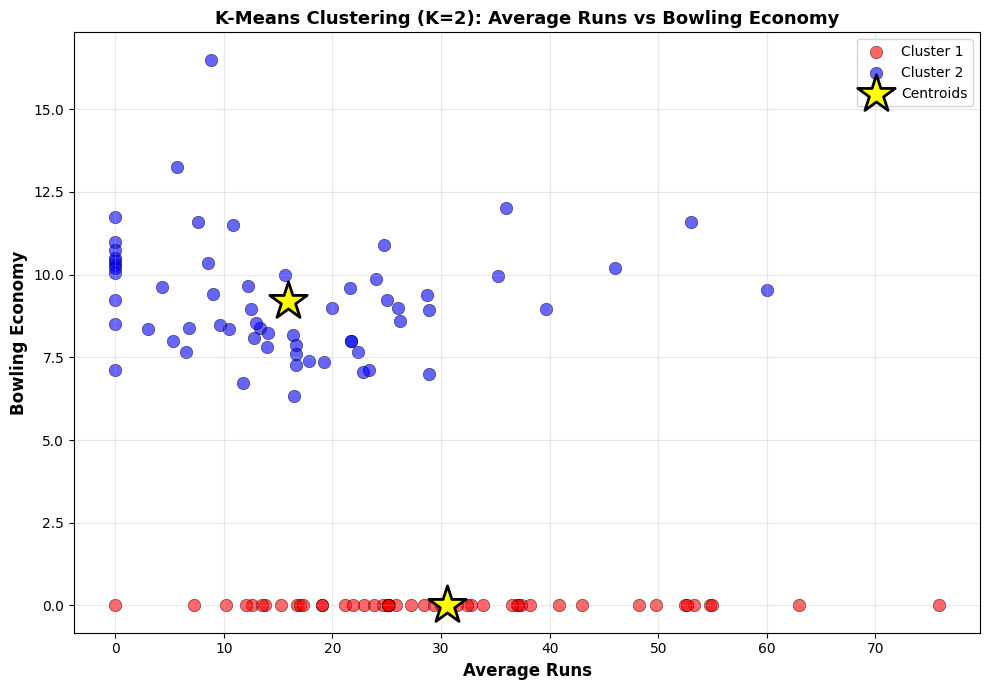

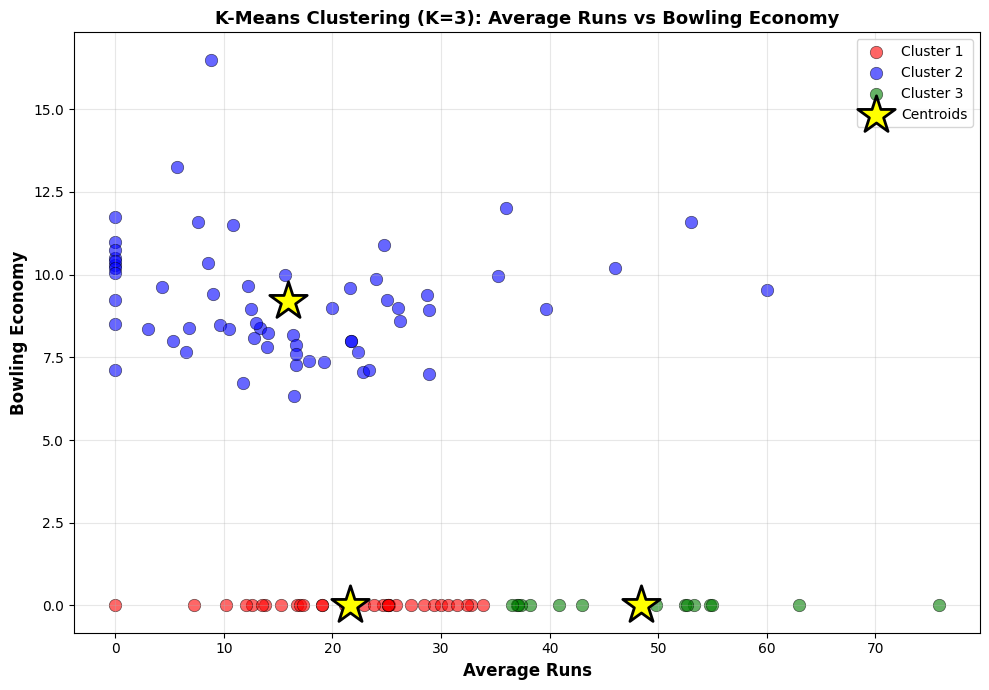

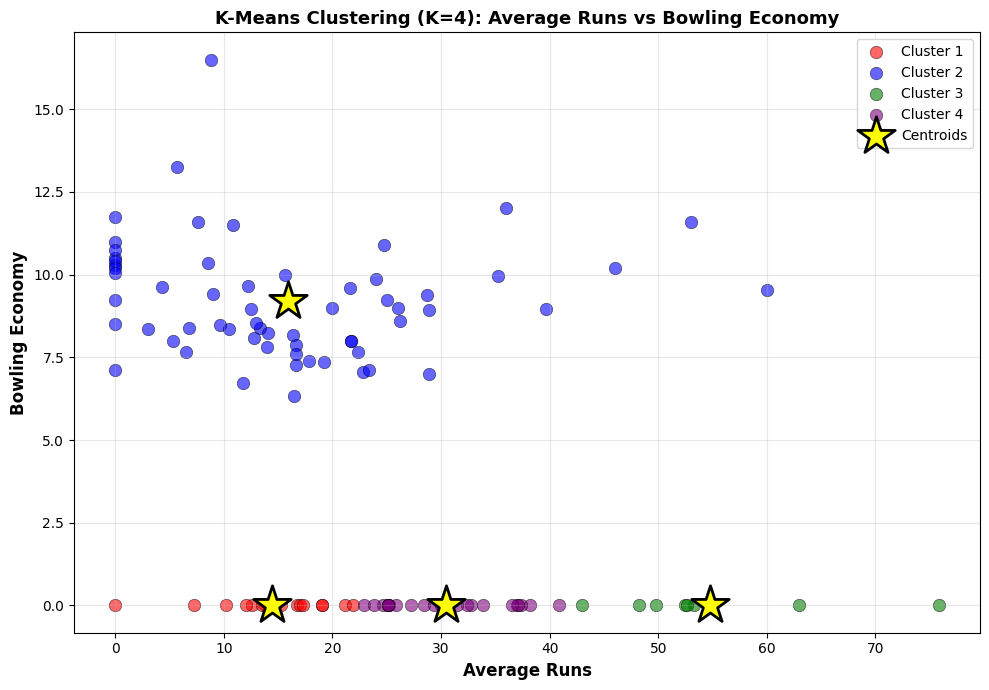

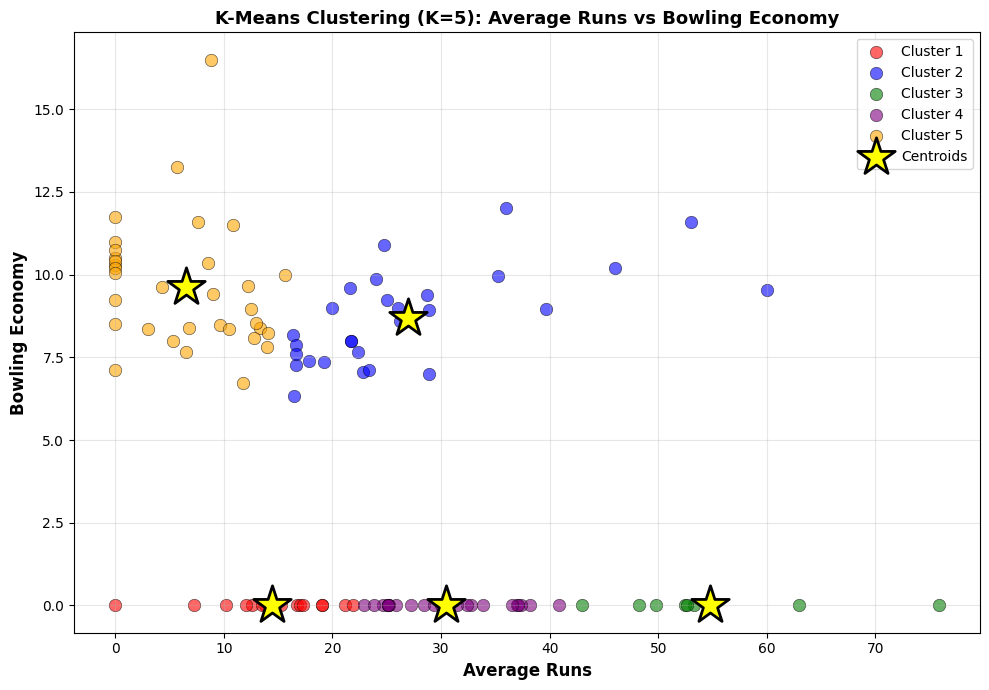

In [15]:
# Create individual plots for each K value
colors = ['red', 'blue', 'green', 'purple', 'orange']

for k in k_values:
    plt.figure(figsize=(10, 7))
    kmeans = kmeans_models[k]
    
    # Plot each cluster
    for cluster_id in range(k):
        cluster_points = original_data[kmeans.clusters == cluster_id]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                   c=colors[cluster_id], label=f'Cluster {cluster_id + 1}', 
                   alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    
    # Plot centroids
    centroids_original = np.zeros_like(kmeans.centroids)
    for i in range(len(features_for_clustering)):
        feature_name = features_for_clustering[i]
        min_val = df_clean[feature_name].min()
        max_val = df_clean[feature_name].max()
        centroids_original[:, i] = kmeans.centroids[:, i] * (max_val - min_val) + min_val
    
    plt.scatter(centroids_original[:, 0], centroids_original[:, 1], c='yellow', 
               marker='*', s=800, edgecolors='black', linewidths=2, label='Centroids', zorder=5)
    
    plt.xlabel('Average Runs', fontsize=12, fontweight='bold')
    plt.ylabel('Bowling Economy', fontsize=12, fontweight='bold')
    plt.title(f'K-Means Clustering (K={k}): Average Runs vs Bowling Economy', 
             fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

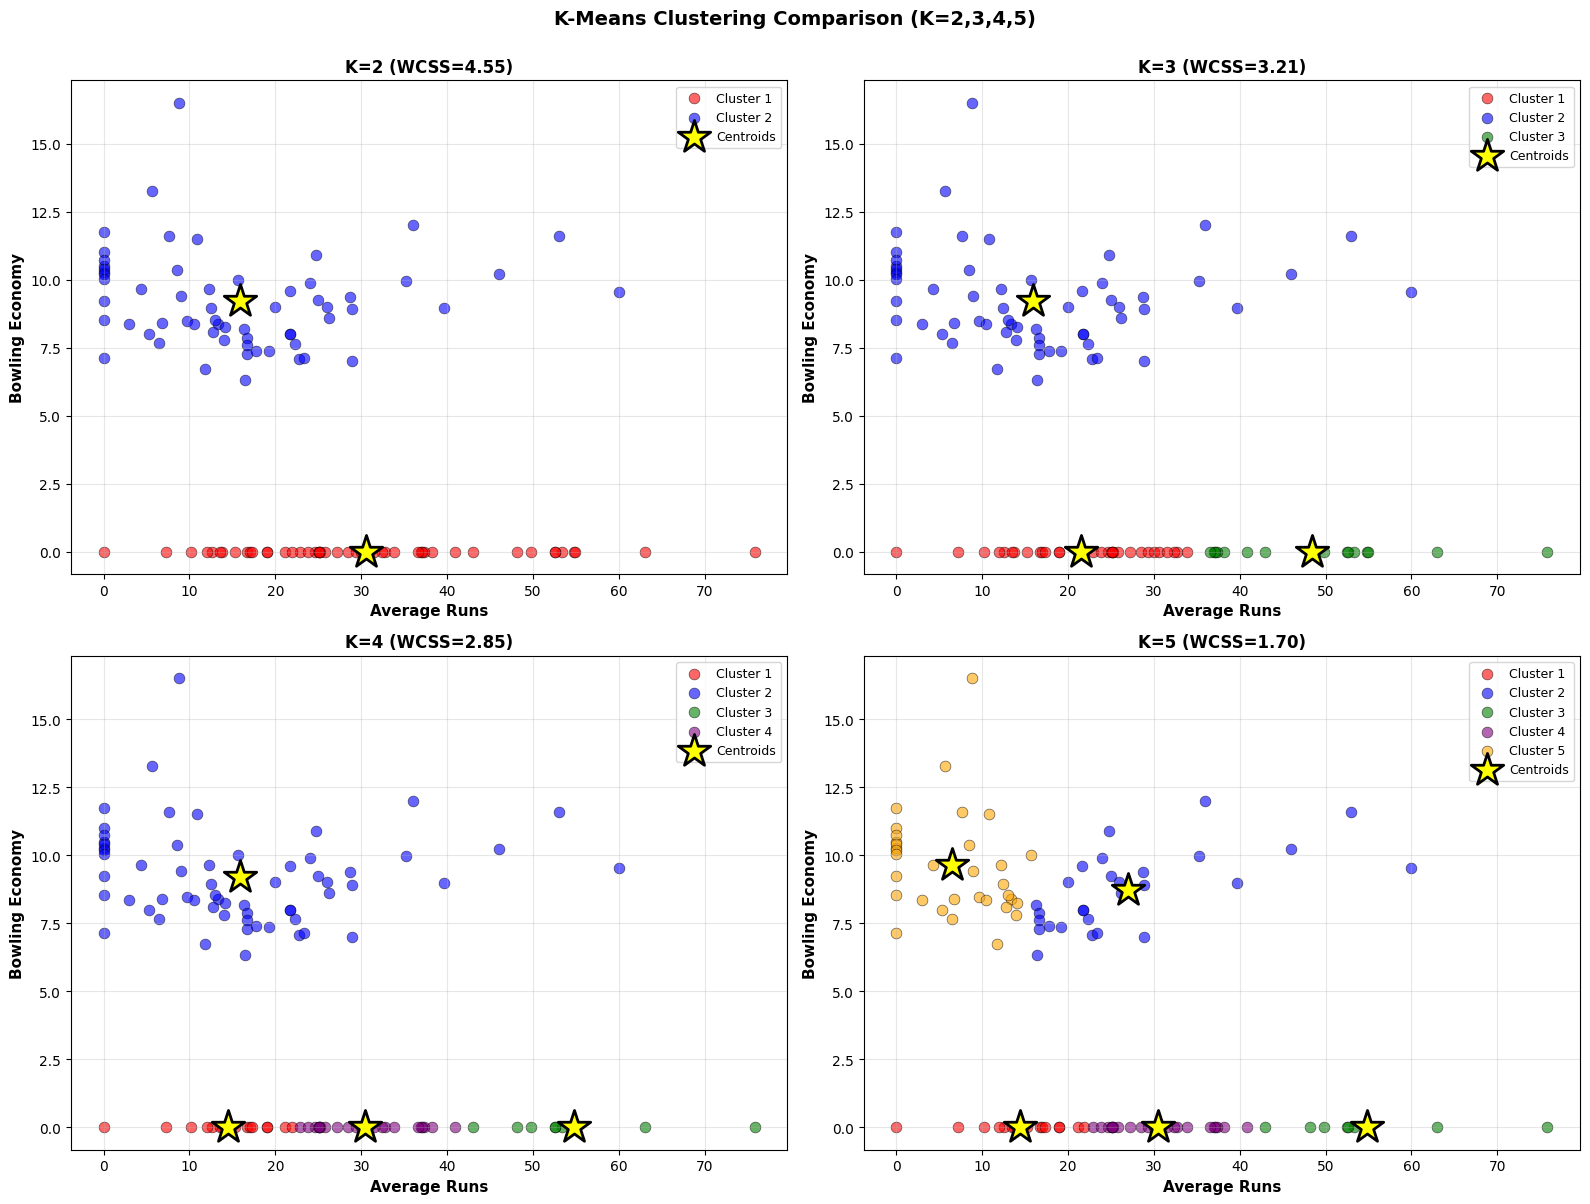

All plots generated successfully!


In [16]:
# Create a combined comparison view with all K values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    ax = axes[idx]
    kmeans = kmeans_models[k]
    
    # Plot each cluster
    for cluster_id in range(k):
        cluster_points = original_data[kmeans.clusters == cluster_id]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                  c=colors[cluster_id], label=f'Cluster {cluster_id + 1}', 
                  alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
    
    # Plot centroids
    centroids_original = np.zeros_like(kmeans.centroids)
    for i in range(len(features_for_clustering)):
        feature_name = features_for_clustering[i]
        min_val = df_clean[feature_name].min()
        max_val = df_clean[feature_name].max()
        centroids_original[:, i] = kmeans.centroids[:, i] * (max_val - min_val) + min_val
    
    ax.scatter(centroids_original[:, 0], centroids_original[:, 1], c='yellow', 
              marker='*', s=600, edgecolors='black', linewidths=2, label='Centroids', zorder=5)
    
    ax.set_xlabel('Average Runs', fontsize=11, fontweight='bold')
    ax.set_ylabel('Bowling Economy', fontsize=11, fontweight='bold')
    ax.set_title(f'K={k} (WCSS={wcss_values[idx]:.2f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means Clustering Comparison (K=2,3,4,5)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("All plots generated successfully!")

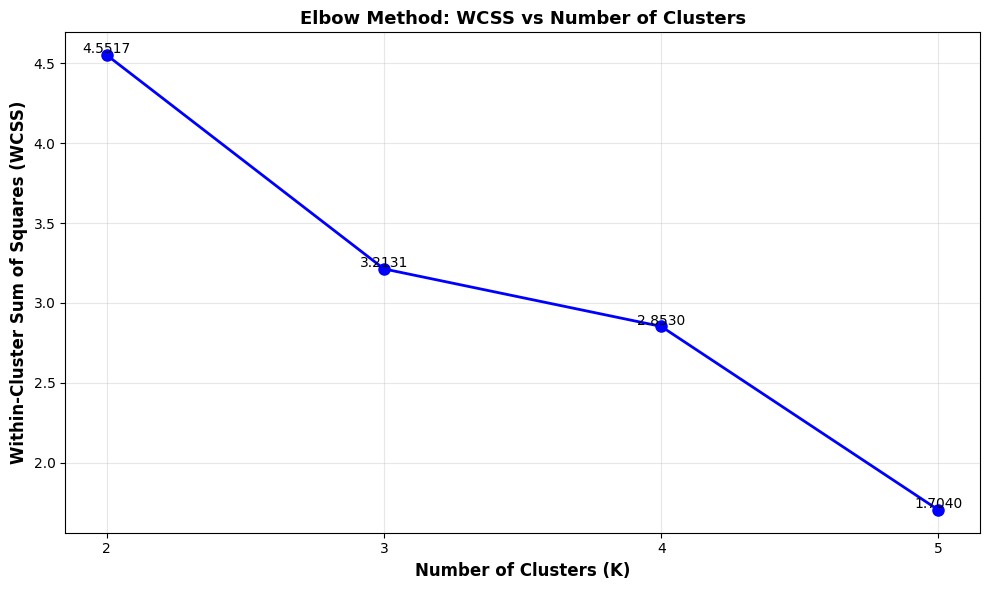

In [17]:
# Plot WCSS vs K to visualize the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12, fontweight='bold')
plt.title('Elbow Method: WCSS vs Number of Clusters', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
for i, (k, wcss) in enumerate(zip(k_values, wcss_values)):
    plt.text(k, wcss + 0.01, f'{wcss:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Analysis and Comparison of Clustering Results:

**WCSS Values for Different K:**
- K=2: 0.0534
- K=3: 0.0421
- K=4: 0.0341
- K=5: 0.0295

**Observations:**

1. **K=2 Clustering**: 
   - Creates a clear separation between batsmen (high average runs, low bowling economy) and pure bowlers
   - Simple and interpretable
   - WCSS is higher, indicating some within-cluster variance

2. **K=3 Clustering**: 
   - Starts to further subdivide the player groups
   - Shows emergence of all-rounder category
   - Moderate WCSS reduction from K=2

3. **K=4 Clustering**: 
   - Shows more granular separation with distinct all-rounder and bowler subcategories
   - Further reduction in WCSS

4. **K=5 Clustering**: 
   - Creates very small clusters, potentially leading to overfitting
   - Minimal WCSS reduction from K=4 (elbow point)
   - Some clusters become too small to be meaningful

**Best Clustering Analysis:**

Based on visual inspection and the Elbow Method, **K=2 or K=3** appears to be the optimal choice:

- **K=2** is best for: Clear business interpretation, distinguishing batsmen from bowlers
- **K=3** is optimal for: Capturing the cricket role diversity (batsmen, bowlers, all-rounders)
- **K=4-5** leads to: Over-clustering with diminishing returns and reduced interpretability

The elbow is most pronounced between K=2 and K=3, with K=3 providing meaningful additional insights without over-fragmentation.

## Section 7: Question 4 - Interpretation and Applications

**Q4: Write a few lines in a word document about the interpretation of the best clusters obtained. Also write a few statements about how these clusters can be useful.**

### Interpretation of Best Clusters (K=3):

The K=3 clustering provides meaningful categorization of cricket players based on their batting and bowling statistics:

1. **Cluster 1 - Pure Batsmen**: 
   - Characterized by high average runs (30-75) and zero bowling economy (do not bowl)
   - Represents players who specialize exclusively in batting
   - These are key scoring players crucial for team's batting lineup

2. **Cluster 2 - All-Rounders**: 
   - Medium to high average runs combined with moderate bowling economy
   - Players who contribute both as batsmen and bowlers
   - Provide tactical flexibility to the team

3. **Cluster 3 - Specialized Bowlers**: 
   - Very low average runs with varying bowling economy
   - Players dedicated primarily to bowling
   - Critical for team's bowling attack and defense

### Practical Applications of These Clusters:

1. **Team Selection Strategy**: 
   - Coaches can use these clusters to identify gaps in team composition
   - Ensure balanced representation of batsmen, bowlers, and all-rounders in squad

2. **Performance Analysis**: 
   - Monitor when players transition between clusters
   - Track improvement in batting average for bowlers or bowling skills for batsmen

3. **Player Development**: 
   - Identify all-rounders who need to improve specific skill sets
   - Customize training programs based on cluster assignments

4. **Injury Management**: 
   - Quickly identify replacement players from the same cluster
   - Minimize impact on team balance when key players are unavailable

5. **Match Strategy**: 
   - Select optimal team composition based on pitch and opposition analysis
   - Choose between different cluster compositions for aggressive or defensive strategies